In [23]:
import coderdata as cd
import os
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Correct import for new RDKit
import pubchempy as pcp

In [49]:
import coderdata_processing
import importlib
importlib.reload(coderdata_processing)
from coderdata_processing import min_max_scaling, filter_biomarkers, filter_feature, data_attribute_check, preprocess_experiment_with_footprint, cat_drug_response_features, unify_feature_across_dataset, get_total_mutation_types, summarize_datasets, summarize_df_matrices, min_max_scaling_across_dfs, dip_data_across_dfs, get_cell_id_across_dfs, cat_drug_response_features_across_datasets, dip_experiments_across_dfs

In [25]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [26]:
datasets = ["beataml", "bladder", "ccle", "colorectal", "cptac", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "hcmi", "liver", "mpnst", "nci60", "novartis", "pancreatic", "prism", "sarcoma"]

data_path = '../data/Cancer/coderdata/'
for data_name in datasets:
    cd.download(name=data_name, local_path=data_path)

loaded_datasets = {}
for data_name in datasets:
    print(f"Loading dataset: {data_name}")
    loaded_datasets[data_name] = cd.load(name=data_name, local_path=data_path)

Downloaded 'https://api.figshare.com/v2/file/download/57224264' to '../data/Cancer/coderdata/genes.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224267' to '../data/Cancer/coderdata/beataml_drugs.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224348' to '../data/Cancer/coderdata/beataml_experiments.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224435' to '../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224456' to '../data/Cancer/coderdata/beataml_transcriptomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224459' to '../data/Cancer/coderdata/beataml_proteomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224462' to '../data/Cancer/coderdata/beataml_mutations.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57349832' to '../data/Cancer/coderdata/beataml_samples.csv'
Downloaded 'https://api.figshare.com/v2/file/download

Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/beataml_transcriptomics.csv.gz ... DONE
Importing 'proteomics' from ../data/Cancer/coderdata/beataml_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/beataml_mutations.csv.gz ... DONE
'copy_number' not available for beataml
Importing 'samples' from ../data/Cancer/coderdata/beataml_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/beataml_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz ... DONE
'mirna' not available for beataml
Importing 'experiments' from ../data/Cancer/coderdata/beataml_experiments.tsv.gz ... DONE
'methylation' not available for beataml
'metabolomics' not available for beataml
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/bladder_transcriptomics.

Loading dataset: bladder


DONE
'proteomics' not available for bladder
Importing 'mutations' from ../data/Cancer/coderdata/bladder_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/bladder_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/bladder_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/bladder_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/bladder_drug_descriptors.tsv.gz ... DONE
'mirna' not available for bladder
Importing 'experiments' from ../data/Cancer/coderdata/bladder_experiments.tsv.gz ... DONE
'methylation' not available for bladder
'metabolomics' not available for bladder
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/ccle_transcriptomics.csv.gz ... 

Loading dataset: ccle


...

DONE
'proteomics' not available for pancreatic
Importing 'mutations' from ../data/Cancer/coderdata/pancreatic_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/pancreatic_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/pancreatic_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/pancreatic_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/pancreatic_drug_descriptors.tsv.gz ... DONE
'mirna' not available for pancreatic
Importing 'experiments' from ../data/Cancer/coderdata/pancreatic_experiments.tsv.gz ... DONE
'methylation' not available for pancreatic
'metabolomics' not available for pancreatic
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/prism_transcriptomics.csv.gz ... 

Loading dataset: prism


DONE
Importing 'proteomics' from ../data/Cancer/coderdata/prism_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/prism_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/prism_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/prism_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/prism_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/prism_drug_descriptors.tsv.gz ... DONE
'mirna' not available for prism
Importing 'experiments' from ../data/Cancer/coderdata/prism_experiments.tsv.gz ... DONE
'methylation' not available for prism
'metabolomics' not available for prism
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/sarcoma_transcriptomics.csv.gz ... 

Loading dataset: sarcoma


DONE
'proteomics' not available for sarcoma
Importing 'mutations' from ../data/Cancer/coderdata/sarcoma_mutations.csv.gz ... DONE
'copy_number' not available for sarcoma
Importing 'samples' from ../data/Cancer/coderdata/sarcoma_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/sarcoma_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/sarcoma_drug_descriptors.tsv.gz ... DONE
'mirna' not available for sarcoma
Importing 'experiments' from ../data/Cancer/coderdata/sarcoma_experiments.tsv.gz ... DONE
'methylation' not available for sarcoma
'metabolomics' not available for sarcoma
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE


In [27]:
data_attribute_check(loaded_datasets)

Dataset 'beataml' is missing: copy_number
Dataset 'bladder' is missing: proteomics
Dataset 'ccle' has all required features ✅
Dataset 'colorectal' is missing: proteomics
Dataset 'cptac' is missing: transcriptomics, proteomics, mutations, copy_number, samples, drugs, experiments
Dataset 'ctrpv2' has all required features ✅
Dataset 'fimm' has all required features ✅
Dataset 'gcsi' has all required features ✅
Dataset 'gdscv1' has all required features ✅
Dataset 'gdscv2' has all required features ✅
Dataset 'hcmi' is missing: proteomics, drugs, experiments
Dataset 'liver' has all required features ✅
Dataset 'mpnst' has all required features ✅
Dataset 'nci60' has all required features ✅
Dataset 'novartis' is missing: proteomics
Dataset 'pancreatic' is missing: proteomics
Dataset 'prism' has all required features ✅
Dataset 'sarcoma' is missing: proteomics, copy_number


In [28]:
summary = summarize_datasets(loaded_datasets)

In [29]:
for key, value in summary.items():
    print(f"{key}: ")
    for sub_key, sub_value in value.items():
        print(f"  {sub_key}: ")
        print(sub_value)

beataml: 
  transcriptomics: 
                     dtype  num_null  pct_null  num_inf  num_unique     min  \
column                                                                        
improve_sample_id    int64         0       0.0        0         707  2074.0   
transcriptomics    float64         0       0.0        0    10620832     0.0   
entrez_id            int64         0       0.0        0       19139     1.0   
source              object         0       0.0        0           1     NaN   
study               object         0       0.0        0           1     NaN   

                            max  \
column                            
improve_sample_id  3.074000e+03   
transcriptomics    1.482622e+05   
entrez_id          1.316758e+08   
source                      NaN   
study                       NaN   

                                                      example_values  
column                                                                
improve_sample_id           

In [30]:
include_copy_number = True
include_proteomics = True

to_remove = ["cptac", "hcmi"]
if (include_copy_number):
    new_to_remove = ["beataml", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

if (include_proteomics):
    new_to_remove = ["bladder", "colorectal", "novartis", "pancreatic", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

selected_datasets = {x: loaded_datasets[x] for x in datasets if x not in to_remove}

In [31]:
# unify entries for each feature across datasets 
unified_datasets = {}
unified_datasets["transcriptomics"] = unify_feature_across_dataset(selected_datasets, feature="transcriptomics")
if include_proteomics:
    unified_datasets["proteomics"] = unify_feature_across_dataset(selected_datasets, feature="proteomics")
if include_copy_number:
    unified_datasets["copy_number"] = unify_feature_across_dataset(selected_datasets, feature="copy_number")
# for mutations, need to get total mutation variation types
all_mutation_types = get_total_mutation_types(selected_datasets)
for mut_type in all_mutation_types:
    unified_datasets[f"mutations_{mut_type}"] = unify_feature_across_dataset(selected_datasets, feature="mutations", mutation_type=mut_type)
unique_cell_ids_across_dfs = get_cell_id_across_dfs(unified_datasets)
print(f"Unified features {unified_datasets.keys()} across datasets.")

Unified features dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Frame_Shift_Ins', 'mutations_Start_Codon_Del', 'mutations_In_Frame_Del', "mutations_3'Flank", 'mutations_Stop_Codon_Del', 'mutations_Start_Codon_SNP', 'mutations_Nonstop_Mutation', 'mutations_In_Frame_Ins', 'mutations_Intron', 'mutations_Splice_Site', "mutations_5'UTR", 'mutations_Splice_Region', 'mutations_Silent', 'mutations_Missense_Mutation', 'mutations_Frame_Shift_Del', 'mutations_Nonsense_Mutation', 'mutations_Start_Codon_Ins', 'mutations_Translation_Start_Site', "mutations_3'UTR", "mutations_5'Flank"]) across datasets.


In [32]:
# Normalization
unified_datasets["transcriptomics"] = min_max_scaling_across_dfs(unified_datasets["transcriptomics"], "transcriptomics")
unified_datasets["proteomics"] = min_max_scaling_across_dfs(unified_datasets["proteomics"], "proteomics")
unified_datasets["copy_number"] = min_max_scaling_across_dfs(unified_datasets["copy_number"], "copy_number")

In [33]:
summary2 = summarize_df_matrices(unified_datasets)

In [34]:
print(summary2.keys())

dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Frame_Shift_Ins', 'mutations_Start_Codon_Del', 'mutations_In_Frame_Del', "mutations_3'Flank", 'mutations_Stop_Codon_Del', 'mutations_Start_Codon_SNP', 'mutations_Nonstop_Mutation', 'mutations_In_Frame_Ins', 'mutations_Intron', 'mutations_Splice_Site', "mutations_5'UTR", 'mutations_Splice_Region', 'mutations_Silent', 'mutations_Missense_Mutation', 'mutations_Frame_Shift_Del', 'mutations_Nonsense_Mutation', 'mutations_Start_Codon_Ins', 'mutations_Translation_Start_Site', "mutations_3'UTR", "mutations_5'Flank"])


In [35]:
data_size_ref = {}
for data, value in unified_datasets["transcriptomics"].items():
    data_size_ref[data] = value.shape[0]
print(data_size_ref)

{'ccle': 474, 'ctrpv2': 822, 'fimm': 48, 'gcsi': 528, 'gdscv1': 973, 'gdscv2': 799, 'liver': 62, 'mpnst': 33, 'nci60': 69, 'prism': 473}


In [37]:
# Filter out biomarkers with too few samples
feature_reduced_dfs = filter_biomarkers(unified_datasets, data_size_ref, proportion=1e-2)

Feature mutations_Start_Codon_Del is filtered out due to insufficient samples
Feature mutations_3'Flank is filtered out due to insufficient samples
Feature mutations_Stop_Codon_Del is filtered out due to insufficient samples
Feature mutations_Intron is filtered out due to insufficient samples
Feature mutations_5'UTR is filtered out due to insufficient samples
Feature mutations_Splice_Region is filtered out due to insufficient samples
Feature mutations_Translation_Start_Site is filtered out due to insufficient samples
Feature mutations_3'UTR is filtered out due to insufficient samples
Feature mutations_5'Flank is filtered out due to insufficient samples


In [38]:
dim_reduced_dfs = filter_feature(feature_reduced_dfs)

Feature transcriptomics: selected 4829 out of 19425 features
Feature proteomics: selected 798 out of 12960 features
Feature copy_number: selected 2906 out of 27287 features
Feature mutations_Frame_Shift_Ins: selected 1106 out of 6007 features
Feature mutations_In_Frame_Del: selected 681 out of 5092 features
Feature mutations_Start_Codon_SNP: selected 116 out of 899 features
Feature mutations_Nonstop_Mutation: selected 122 out of 630 features
Feature mutations_In_Frame_Ins: selected 237 out of 697 features
Feature mutations_Splice_Site: selected 5262 out of 15247 features
Feature mutations_Silent: selected 13682 out of 18026 features
Feature mutations_Missense_Mutation: selected 17830 out of 18915 features
Feature mutations_Frame_Shift_Del: selected 3584 out of 13686 features
Feature mutations_Nonsense_Mutation: selected 3521 out of 13426 features
Feature mutations_Start_Codon_Ins: selected 12 out of 12 features


In [39]:
drugs_ref_dfs = {}
for name, data in selected_datasets.items():
    drugs_ref_dfs[name] = data.drugs.drop_duplicates(subset=["improve_drug_id"], inplace=False)

experiments_dfs = {}
metric = "fit_auc"
for name, data in selected_datasets.items():
    experiments_dfs[name] = data.experiments[data.experiments["dose_response_metric"]==metric]

In [47]:
experiments_dfs_sampled = dip_experiments_across_dfs(experiments_dfs, fraction=0.01)

In [51]:
feature_dict_footprint, resp_footprint = preprocess_experiment_with_footprint(experiments_dfs_sampled, drugs_ref_dfs, dim_reduced_dfs, drug_target=None, show_status=True)

Processing dataset: ccle with 115 experiments
Finished processing dataset: ccle with 115 selected samples
Processing dataset: ctrpv2 with 3094 experiments
Finished processing dataset: ctrpv2 with 3094 selected samples
Processing dataset: fimm with 27 experiments
Finished processing dataset: fimm with 27 selected samples
Processing dataset: gcsi with 134 experiments
Finished processing dataset: gcsi with 134 selected samples
Processing dataset: gdscv1 with 2478 experiments
Finished processing dataset: gdscv1 with 2478 selected samples
Processing dataset: gdscv2 with 1154 experiments
Finished processing dataset: gdscv2 with 1154 selected samples
Processing dataset: liver with 45 experiments
Finished processing dataset: liver with 45 selected samples
Processing dataset: mpnst with 3 experiments
Finished processing dataset: mpnst with 3 selected samples
Processing dataset: nci60 with 29699 experiments


[10:20:55] WARNING: not removing hydrogen atom without neighbors
[10:26:01] Explicit valence for atom # 0 Cl, 1, is greater than permitted


Invalid SMILES for drug ID SMI_55935
Skipping experiment 1655422 with drug ID SMI_55935 due to invalid SMILES
Finished processing dataset: nci60 with 29698 selected samples
Processing dataset: prism with 6390 experiments
Finished processing dataset: prism with 6390 selected samples


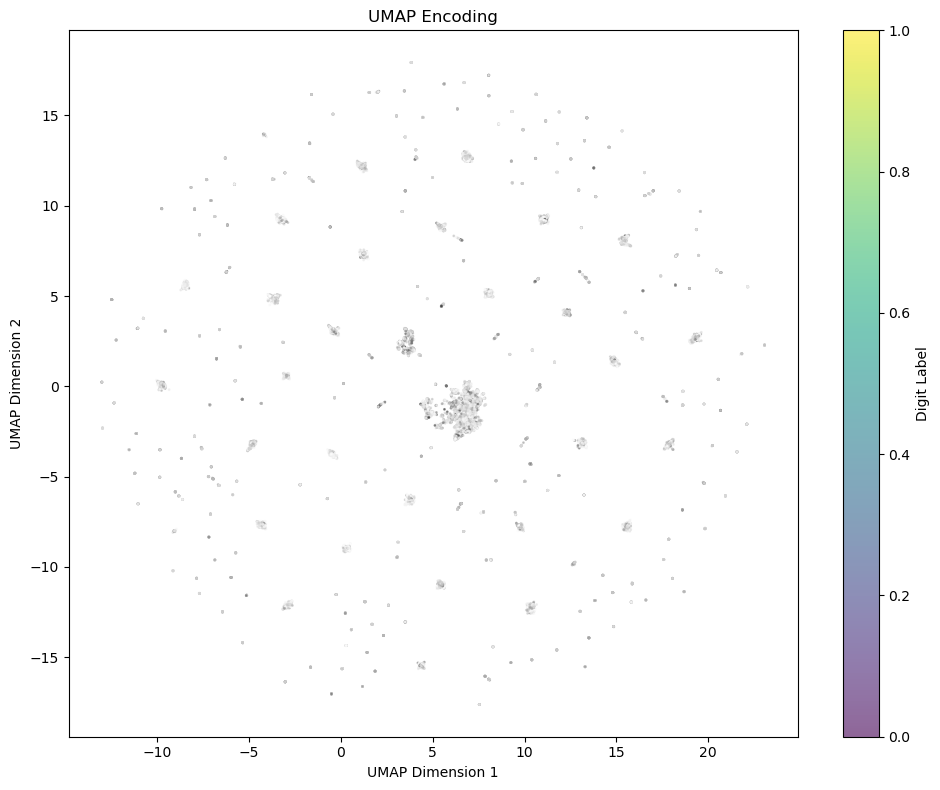

In [52]:
X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])

umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()